<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

epoch    0  train_loss=0.9692  test_loss=0.9138
epoch  200  train_loss=0.0080  test_loss=0.1199
epoch  400  train_loss=0.0031  test_loss=0.0829
epoch  600  train_loss=0.0018  test_loss=0.0674
epoch  800  train_loss=0.0013  test_loss=0.0580
epoch 1000  train_loss=0.0010  test_loss=0.0515
epoch 1200  train_loss=0.0008  test_loss=0.0468
epoch 1400  train_loss=0.0007  test_loss=0.0431
epoch 1600  train_loss=0.0006  test_loss=0.0401
epoch 1800  train_loss=0.0005  test_loss=0.0376


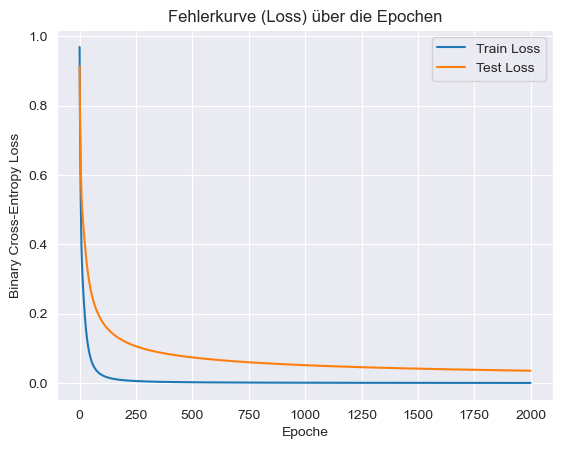


Test-Accuracy: 1.0
 0.99  (true=1)  -> Gratis Gutschein nur heute!!! Jetzt anmelden!
 0.00  (true=0)  -> Hey, kommst du morgen zum Lernen?
 0.91  (true=1)  -> Letzte Chance: Verdiene schnell Geld von zuhause!!!

Neue Nachrichten:
 0.00  HAM   -> Hi, kannst du mir die Matheaufgabe erklären?
 1.00  SPAM  -> GEWINNE 500€ jetzt!!! Klicke http://spam.example
 0.31  HAM   -> Kostenloser Gutschein nur heute!!!


In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1) Mini-Daten: Spam vs. Ham
# =========================================================
texts = [
    "Hey, kommst du morgen zum Lernen?",
    "ACHTUNG!!! Du hast GEWONNEN! Klicke hier für 1000€",
    "Kannst du mir die Hausaufgabe schicken?",
    "Gratis Gutschein nur heute!!! Jetzt anmelden!",
    "Treffen wir uns um 16:00 bei der Bibliothek?",
    "Letzte Chance: Verdiene schnell Geld von zuhause!!!",
    "Schick mir bitte den Link zum Arbeitsblatt.",
    "Du bist ausgewählt: Kostenloses iPhone, nur Klick!",
    "Danke für deine Hilfe :)",
    "JETZT kaufen und 50% sparen!!! http://deal.example"
]

# 0 = Ham, 1 = Spam
y = np.array([0,1,0,1,0,1,0,1,0,1], dtype=float).reshape(-1, 1)

# =========================================================
# 2) Feature-Engineering (erklärbar)
# =========================================================
spam_words = {
    "gratis","kostenlos","gewonnen","gutschein",
    "verdiene","chance","kaufen","sparen","iphone","klick"
}

def featurize(t: str):
    tl = t.lower()
    has_link = 1 if re.search(r"http[s]?://|www\.", tl) else 0
    has_money = 1 if ("€" in t) or ("eur" in tl) or ("geld" in tl) else 0
    exclam = t.count("!")
    letters = [c for c in t if c.isalpha()]
    upper_ratio = (
        sum(c.isupper() for c in letters) / max(1, len(letters))
        if letters else 0.0
    )
    length = len(t)
    word_hits = sum(1 for w in spam_words if w in tl)
    return np.array(
        [has_link, has_money, exclam, upper_ratio, length, word_hits],
        dtype=float
    )

X = np.vstack([featurize(t) for t in texts])  # (N, 6)

# =========================================================
# 3) Standardisierung
# =========================================================
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True) + 1e-8
Xn = (X - X_mean) / X_std

# =========================================================
# 4) Train/Test Split
# =========================================================
idx = np.arange(len(Xn))
np.random.seed(0)
np.random.shuffle(idx)

split = int(0.7 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train, y_train = Xn[train_idx], y[train_idx]
X_test,  y_test  = Xn[test_idx],  y[test_idx]

# =========================================================
# 5) Neuronales Netz (from scratch)
# =========================================================
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def bce_loss(yhat, ytrue):
    eps = 1e-8
    yhat = np.clip(yhat, eps, 1 - eps)
    return -(ytrue*np.log(yhat) + (1-ytrue)*np.log(1-yhat)).mean()

# Netzwerkgröße
n_in = X_train.shape[1]   # 6
n_hidden = 8
n_out = 1

# Initialisierung
rng = np.random.default_rng(0)
W1 = rng.normal(0, 0.5, size=(n_in, n_hidden))
b1 = np.zeros((1, n_hidden))
W2 = rng.normal(0, 0.5, size=(n_hidden, n_out))
b2 = np.zeros((1, n_out))

lr = 0.1
epochs = 2000

# =========================================================
# 6) Training + Fehlerkurve
# =========================================================
loss_history = []
test_loss_history = []

for epoch in range(epochs):

    # ---------- Forward ----------
    z1 = X_train @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    yhat = sigmoid(z2)

    loss = bce_loss(yhat, y_train)
    loss_history.append(loss)

    # ---------- Test-Loss (nur messen) ----------
    yhat_test = sigmoid(relu(X_test @ W1 + b1) @ W2 + b2)
    test_loss = bce_loss(yhat_test, y_test)
    test_loss_history.append(test_loss)

    # ---------- Backprop ----------
    dz2 = (yhat - y_train) / len(X_train)
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * relu_deriv(z1)
    dW1 = X_train.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)

    # ---------- Update ----------
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 200 == 0:
        print(f"epoch {epoch:4d}  train_loss={loss:.4f}  test_loss={test_loss:.4f}")

# =========================================================
# 7) Fehlerkurve plotten
# =========================================================
plt.figure()
plt.plot(loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.xlabel("Epoche")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Fehlerkurve (Loss) über die Epochen")
plt.legend()
plt.show()

# =========================================================
# 8) Auswertung
# =========================================================
def predict_proba(X):
    return sigmoid(relu(X @ W1 + b1) @ W2 + b2)

proba_test = predict_proba(X_test)
pred_test = (proba_test >= 0.5).astype(int)

acc = (pred_test == y_test.astype(int)).mean()
print("\nTest-Accuracy:", acc)

for t, p, yy in zip([texts[i] for i in test_idx],
                    proba_test.flatten(),
                    y_test.flatten()):
    print(f"{p:5.2f}  (true={int(yy)})  -> {t}")

# =========================================================
# 9) Neue Nachrichten testen
# =========================================================
def predict_texts(new_texts):
    Xnew = np.vstack([featurize(t) for t in new_texts])
    Xnew = (Xnew - X_mean) / X_std
    return predict_proba(Xnew).flatten()

new_msgs = [
    "Hi, kannst du mir die Matheaufgabe erklären?",
    "GEWINNE 500€ jetzt!!! Klicke http://spam.example",
    "Kostenloser Gutschein nur heute!!!"
]

print("\nNeue Nachrichten:")
for msg, p in zip(new_msgs, predict_texts(new_msgs)):
    label = "SPAM" if p >= 0.5 else "HAM"
    print(f"{p:5.2f}  {label:4s}  -> {msg}")
